In [1]:
import torch # pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import cv2, os, json, gc, math
import numpy as np
import pandas as pd
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

from utils.Plotter.index import Plotter
from Network.index import ModelNetwork
from utils.index import *

In [2]:
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    torch.cuda.synchronize()

gc.collect()
print(torch.__version__)              # versão do PyTorch
print(torch.cuda.is_available())      # True se detectou a GPU
print(torch.cuda.get_device_name(0))  # nome da GPU
pd.set_option('display.max_columns', None)

2.7.1+cu118
True
Quadro P6000


# HISTÓRICO DE TREINAMENTO

In [3]:
df = []

for bakup in os.listdir('Backup/'):
    path = f'Backup/{bakup}/info.json'

    with open(path, 'r', encoding='utf-8') as file:
        file = json.loads(file.read())

    info = {}
    for key, value in file.items():
        info.update(value)

    if not info.get('dataset'):
        info['dataset'] = 'dataset0'

    # MODELOS DE ANTES DO EMA E DOS TRIALS: TREINADOS SEM EMA, UMA RODADA SO
    info.setdefault('ema', False)
    info.setdefault('trial', 0)

    info['id'] = int(info.get('path').split('_')[-1])
    df.append(info)


df = pd.DataFrame(df).sort_values(by='id')
df.head()

,path,loss,scheduler,epochs,batch_size,ema,trial,val_iou,test_iou,network,dataset,img_size,lr,dropout,num_filters,n_trials,val_size,test_size,n_images,classes,channels,mean,id
3,model_1,dice_focal,plateau,100,2,True,0,0.694184,0.703248,standard,dataset_74,"[128, 128, 128]",0.0001,0.05,32,1,0.047619,0.045455,"{'total': 220, 'train': 200, 'val': 10, 'test'...",1,1,0.703248,1
6,model_2,dice_focal,plateau,100,2,True,0,0.721285,0.731304,unet3d_v2,dataset_74,"[128, 128, 128]",0.0001,0.05,32,1,0.047619,0.045455,"{'total': 220, 'train': 200, 'val': 10, 'test'...",1,1,0.731304,2
4,model_3,dice_focal,plateau,100,2,True,0,0.729116,0.735927,segresnet,dataset_74,"[128, 128, 128]",0.0001,0.05,32,1,0.047619,0.045455,"{'total': 220, 'train': 200, 'val': 10, 'test'...",1,1,0.735927,3
5,model_4,dice_focal,plateau,100,2,True,0,0.649518,0.658620,resaceunet,dataset_74,"[128, 128, 128]",0.0001,0.05,32,1,0.047619,0.045455,"{'total': 220, 'train': 200, 'val': 10, 'test'...",1,1,0.658620,4
2,model_5,dice_focal,plateau,100,2,True,0,0.724755,0.729462,macnn,dataset_74,"[128, 128, 128]",0.0001,0.05,32,1,0.047619,0.045455,"{'total': 220, 'train': 200, 'val': 10, 'test'...",1,1,0.729462,5


# ANÁLISE DE VARIAÇÕES

alvo: network | fixos: {'dataset': 'dataset_74', 'loss': 'dice_focal', 'lr': 0.0001, 'dropout': 0.05, 'img_size': '[128, 128, 128]'}


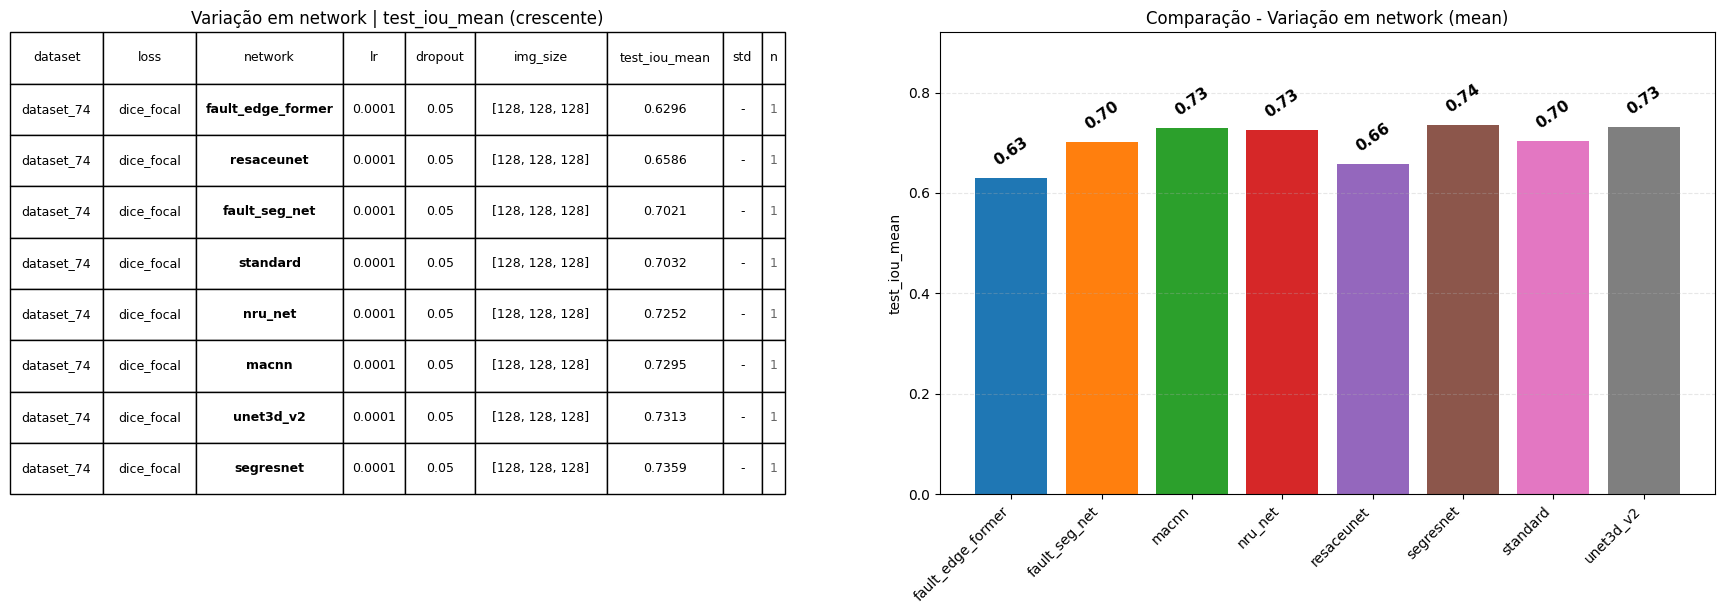

In [ ]:
class VariationAnalysis:
    MODES       = ('min', 'max', 'mean', 'median')
    COUNT       = 'n'
    MAX_STR_LEN = 24          # SÓ CORTA VALORES EXTREMOS, O RESTO CABE REDUZINDO A FONTE
    PADDING     = 2           # CARACTERES DE FOLGA POR COLUNA
    CHAR_WIDTH  = 0.62        # LARGURA DE UM CARACTERE EM FRAÇÃO DA FONTE
    ROW_HEIGHT  = 0.55        # FRAÇÃO DA LINHA OCUPADA PELA FONTE
    FONT        = (6, 14)
    FIG_WIDTH   = 22
    ROW_INCHES  = 0.5
    HEIGHT      = (5, 20)
    MARGIN      = 0.25        # FOLGA ACIMA DAS BARRAS PARA OS RÓTULOS

    def __init__(self, df, variations, id=None, metric='test_mre_mm', mode='mean', asc=True):
        self.df         = df
        self.variations = variations
        self.id         = id
        self.metric     = metric
        self.mode       = mode
        self.asc        = asc
        self.label      = f'{metric}_{mode}'

    def update(self):
        missing = [col for col in [*self.variations, self.metric, self.id] if col and col not in self.df.columns]

        if missing:
            raise ValueError(f'colunas ausentes no df: {missing}')

        if self.mode not in self.MODES:
            raise ValueError(f"mode '{self.mode}' inválido, use um de {self.MODES}")

        df = self.df.copy()
        df[self.metric] = pd.to_numeric(df[self.metric], errors='coerce')
        df = df.dropna(subset=[self.metric]).reset_index(drop=True)

        for col in self.variations:
            numeric = pd.to_numeric(df[col], errors='coerce')
            df[col] = numeric if numeric.notna().sum() == df[col].notna().sum() else df[col].astype(str)

        if self.id:
            df[self.id] = df[self.id].astype(str)

        self.df = df

    def aggregate(self, df):
        groups = df.groupby(self.variations, dropna=False)[self.metric]
        agg    = groups.agg([self.mode, 'std', 'size']).rename(columns={self.mode: self.label, 'size': self.COUNT}).reset_index()

        if self.id and self.mode in ('min', 'max'):
            agg.insert(len(self.variations), self.id, df.loc[groups.agg(f'idx{self.mode}').values, self.id].values)

        return agg.sort_values(self.label, ascending=self.asc, kind='stable')

    # UMA FIGURA POR HIPERPARÂMETRO PARA CADA COMBINAÇÃO FIXA DOS OUTROS
    def plot(self):
        for var in self.variations:
            fixed  = [col for col in self.variations if col != var]
            groups = self.df.groupby(fixed, dropna=False) if fixed else [(None, self.df)]

            for _, group in groups:
                if group[var].nunique(dropna=False) <= 1:
                    continue

                print(f'alvo: {var} | fixos: {group.iloc[0][fixed].to_dict()}')
                self.showComparison(self.aggregate(group), var)

    # TABELA À ESQUERDA E BARRAS COM DESVIO À DIREITA
    def showComparison(self, table, var):
        order  = 'crescente' if self.asc else 'decrescente'
        chart  = table.sort_values(var, kind='stable')
        values = chart[self.label]
        low    = min(0, values.min())
        high   = max(0, values.max())
        pad    = self.MARGIN * ((high - low) or 1)
        limits = (low - pad * (low < 0), high + pad)
        height = len(table) * self.ROW_INCHES + 2    # TÍTULO E CABEÇALHO

        plt.figure(figsize=(self.FIG_WIDTH, min(max(height, self.HEIGHT[0]), self.HEIGHT[1])))
        plt.subplot(1, 2, 1)
        self.showTable(table, var, f'Variação em {var} | {self.label} ({order})')

        plt.subplot(1, 2, 2)
        Plotter(dict(zip(chart[var].astype(str), values)), limits=limits, title=f'Comparação - Variação em {var} ({self.mode})', stds=chart['std'].tolist())
        plt.ylabel(self.label)
        plt.show()

    def showTable(self, table, boldCol, title):
        cells = table.copy()

        for col in (self.label, 'std'):
            cells[col] = cells[col].map(lambda x: f'{x:.4f}' if pd.notna(x) else '-')

        cells = cells.astype(str)

        if self.id in cells.columns:
            cells[self.id] = cells[self.id].map(os.path.basename)

        for col in cells.columns.drop([self.label, 'std', self.COUNT]):
            cells[col] = cells[col].where(cells[col].str.len() <= self.MAX_STR_LEN, cells[col].str.slice(0, self.MAX_STR_LEN - 1) + '…')

        ax         = plt.gca()
        box        = ax.get_position()
        figW, figH = ax.figure.get_size_inches()
        widths     = [max(len(col), cells[col].str.len().max()) + self.PADDING for col in cells.columns]
        fitW       = figW * box.width * 72 / (sum(widths) * self.CHAR_WIDTH)    # 72 PT POR POLEGADA
        fitH       = figH * box.height * 72 / (len(cells) + 1) * self.ROW_HEIGHT
        styles     = {boldCol: {'fontweight': 'bold'}, self.COUNT: {'color': '0.4'}}

        ax.axis('off')
        grid = ax.table(cellText=cells.values, colLabels=cells.columns, colWidths=[width / sum(widths) for width in widths], cellLoc='center', bbox=[0, 0, 1, 1])
        grid.auto_set_font_size(False)
        grid.set_fontsize(max(self.FONT[0], min(self.FONT[1], fitW, fitH)))

        for (row, col), cell in grid.get_celld().items():
            if row > 0 and cells.columns[col] in styles:
                cell.set_text_props(**styles[cells.columns[col]])

        plt.title(title)


variations = ['dataset', 'loss', 'network', 'lr', 'dropout', 'img_size']
analysis   = VariationAnalysis(df, variations, id='path', metric='test_iou', mode='mean', asc=True)
analysis.update()
analysis.plot()